## import libs

- Import all libraries used across data loading, preprocessing, modeling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## read the data

- Load the CSV into a DataFrame and inspect the first few rows.
- Confirm expected columns: `label` and `text`.

In [2]:
df = pd.read_csv("./dataset/hatevsoffensive_language.csv")
df.head(5)

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [3]:
# Create output directories for figures
import os
for d in [
    './outputs/figures/eda',
    './outputs/figures/comparisons',
    './outputs/figures/training_curves',
    './outputs/figures/confusion_matrices',
]:
    os.makedirs(d, exist_ok=True)
    print(f'Created {d}')


Created ./outputs/figures/eda
Created ./outputs/figures/comparisons
Created ./outputs/figures/training_curves
Created ./outputs/figures/confusion_matrices


In [4]:
df_text = df[['text']]
df_text.head(5)

,text
0,!!! RT @mayasolovely: As a woman you shouldn't...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## text Preprocessing

- Define helper functions to clean tweet-style text (URLs, emojis, punctuation, etc.).
- Combine them into a single cleaning pipeline and apply it to the full dataset.
- Verify the cleaned output is a string (not a token list) before tokenization.
- Goal: reduce noise while keeping enough signal for sequence models (RNN/LSTM).

In [5]:
# preprocess the text
import re

# remove urls
def remove_urls(text): 
    """
    This function will try to remove URL present in out dataset and replace it with space using regex library.

    Input Args:
        text: strings of text that may contain URLs.

    Output Args:
        text: URLs replaces with text
    """
    url_pattern = re.compile(r'http[s]?: //\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emoji(string): 
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251""]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)

def removeunwanted_characters(document): 
    """Remove mentions/hashtags/punctuation and normalize whitespace.

    Notes:
        - Removes @mentions and #hashtags.
        - Replaces non-alphanumeric characters with spaces.
        - Removes emojis via `remove_emoji()`.

    Args:
        document (str): Raw text.

    Returns:
        str: Cleaned text.
    """
    document = re.sub('@[A-Za-z0-9_]+'," ", document) #mentions
    document = re.sub('#[A-Za-z0-9_]+', " ", document) #hashtags 
    document = re.sub('[^A-Za-z0-9 ]+', " ", document)  #punctuations
    document = remove_emoji(document)     # emojis
    document = document.replace(" ", " ") # double spaces
    return document.strip()

text_removed_unwanted = df['text'].apply(removeunwanted_characters)
text_removed_unwanted.head(4)

0    RT    As a woman you shouldn t complain about ...
1    RT    boy dats cold tyga dwn bad for cuffin da...
2    RT   Dawg  RT    You ever fuck a bitch and she...
3                       RT      she look like a tranny
Name: text, dtype: str

### Helper functions: `remove_punct` and tokenize

In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk import word_tokenize

from nltk.tokenize import RegexpTokenizer

def remove_punct(text): 
    """
     This function removes the punctutations present in our text data.

     Input Args:
         text: text data.

     Returns:
         text: cleaned text.
    """
    tokenizer = RegexpTokenizer(r"\w+")
    lst = tokenizer.tokenize(" ".join(text))
    return lst

remove_punct("He did not try to navigate: after the!!!! first bold flight, for,,,,, the reaction!!!!had taken??????? something out of his soul.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['H',
 'e',
 'd',
 'i',
 'd',
 'n',
 'o',
 't',
 't',
 'r',
 'y',
 't',
 'o',
 'n',
 'a',
 'v',
 'i',
 'g',
 'a',
 't',
 'e',
 'a',
 'f',
 't',
 'e',
 'r',
 't',
 'h',
 'e',
 'f',
 'i',
 'r',
 's',
 't',
 'b',
 'o',
 'l',
 'd',
 'f',
 'l',
 'i',
 'g',
 'h',
 't',
 'f',
 'o',
 'r',
 't',
 'h',
 'e',
 'r',
 'e',
 'a',
 'c',
 't',
 'i',
 'o',
 'n',
 'h',
 'a',
 'd',
 't',
 'a',
 'k',
 'e',
 'n',
 's',
 'o',
 'm',
 'e',
 't',
 'h',
 'i',
 'n',
 'g',
 'o',
 'u',
 't',
 'o',
 'f',
 'h',
 'i',
 's',
 's',
 'o',
 'u',
 'l']

### remove stopwords

In [7]:
nltk.download("stopwords")
from  nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# get the stopwords
stop_words = set(stopwords.words("english"))

# add custom stopwords
custom_stopwords = ['@', 'RT', 'u', 'i', 'co']
stop_words.update(custom_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def remove_stopwords(text_tokens): 
    """
     This function removes all the stopwords present in out text tokens.
     
     Input Args:
         text_tokens: tokenize input of our datasets.
     Returns:
         result_tokens: list of token without stopword.
    """
    result_tokens = []
    for token in text_tokens:
        if token not in stop_words:
            result_tokens.append(token)
    return result_tokens

remove_stopwords(['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.'
])

['He',
 'try',
 'navigate',
 'first',
 'bold',
 'flight',
 ',',
 'reaction',
 'taken',
 'something',
 'soul',
 '.']

In [9]:
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

def lemmatization(token_text): 
    """
    This function performs the lemmatization operations as explained above.

    Input Args:
        token_text: list of tokens.

    Returns:
        lemmatized_tokens: list of lemmatized tokens.
    """
    wordnet = WordNetLemmatizer()
    lemmatized_tokens = [wordnet.lemmatize(token.lower(), pos = 'v') for token in token_text]
    return lemmatized_tokens

lemmatization("Should we go walking or swimming".split())


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['should', 'we', 'go', 'walk', 'or', 'swim']

In [10]:
from nltk.stem import PorterStemmer

def stemming(text): 
  """
    This function performs stemming operations.

    Input Args:
        token_text: list of tokenize text.

    Returns:
        stemm_tokes: list of stemmed tokens.
    """
  porter = PorterStemmer()
  stemm_tokens = [porter.stem(token) for token in text]
  return stemm_tokens

# test
stemming(['Connects','Connecting','Connections','Connected','Connection','Connectings','Connect' ])

['connect', 'connect', 'connect', 'connect', 'connect', 'connect', 'connect']

In [11]:
def lower_order(text): 
    """
    This function converts all the text in input text to lower order.

    Input Args:
        token_text : input text.

    Returns:
        small_order_text : text converted to small/lower order.
    """
    return  text.lower()

lower_order("This Is some Normalized TEXT")

'this is some normalized text'

In [12]:
def remove_contradictions(text): 
    """
    This function replaces the contractions in text with their expanded form.

    Input Args:
        text: input text.

    Returns:
        expanded_text: text with contractions replaced by their expanded form.
    """
    contractions_dict = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am",
    "aint": "am not",
    "arent": "are not",
    "cant": "cannot",
    }

    contractions_re = re.compile('(%s)' % '|'.join(contractions_dict.keys()))

    def expand_contractions(s, contractions_dict=contractions_dict):
        def replace(match):
            return contractions_dict[match.group(0) ]
        return contractions_re.sub(replace, s)

    expanded_text = expand_contractions(text)
    return expanded_text
  
remove_contradictions("I can't go to the party because I won't have time.")

'I cannot go to the party because I will not have time.'

In [13]:
def text_cleaning_pipeline(dataset, rule = "lemmatize"): 
  """
  This function cleans up the text, changes order, remove url, emojis and unwanted characters
  turns them to token and then lemmatize or stemm them according to the rule passed

  Input Args:
    dataset: the data col to perform these operations on
    rule: Whether to lemmatize or stemm it (Default is lemmatize)

  Output:
    cleaned list of tokens
  """
  # Remove URLs
  data = remove_urls(dataset)

  # Remove emojis
  data = remove_emoji(dataset)

  # Remove contractions
  data = remove_contradictions(dataset)

  # Remove all other unwanted characters.
  data = removeunwanted_characters(dataset)

  # Convert the input to small/lower order.
  data = lower_order(dataset)

  # Create tokens.
  tokens = data.split()

  # Remove stopwords
  tokens = remove_stopwords(tokens)

  # Remove punctuations
  tokens = remove_punct(tokens)

  if rule == "lemmatize":
    tokens = lemmatization(tokens)
  elif rule == "stem":
    tokens = stemming(tokens)
  else:
    print("Pick between lemmatize or stem")

  return " ".join(tokens)

# test
text_cleaning_pipeline( "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱")

'hello gabe_flomo still want us hit new sushi spot lmk free cuz can t go next weekend since swim sushibros rawfish'

In [14]:
# apply on real data
df["cleaned"] = df['text'].apply(lambda data: text_cleaning_pipeline(data))
df["cleaned"].head(4)

0    rt mayasolovely woman complain clean house amp...
1    rt mleew17 boy dats cold tyga dwn bad cuffin d...
2    rt urkindofbrand dawg rt 80sbaby4life ever fuc...
3          rt c_g_anderson viva_based look like tranny
Name: cleaned, dtype: str

In [15]:
print(df.columns)
print(type(df["cleaned" ].iloc[0]))  # should be str, not list

Index(['label', 'text', 'cleaned'], dtype='str')
<class 'str'>


## Visualization

- Explore the cleaned corpus to understand common terms and overall noise.
- Generate a word frequency list and a word cloud.

In [16]:
from collections import Counter

all_words = " ".join(df['cleaned']).split()

common_words = Counter(all_words).most_common(20)
print(common_words)

[('bitch', 11481), ('rt', 7647), ('t', 4689), ('hoe', 4359), ('128514', 3241), ('get', 3081), ('co', 3005), ('http', 2915), ('like', 2862), ('fuck', 2267), ('pussy', 2160), ('8220', 1726), ('8221', 1682), ('s', 1651), ('ass', 1579), ('shit', 1312), ('go', 1278), ('8230', 1265), ('nigga', 1229), ('trash', 1167)]


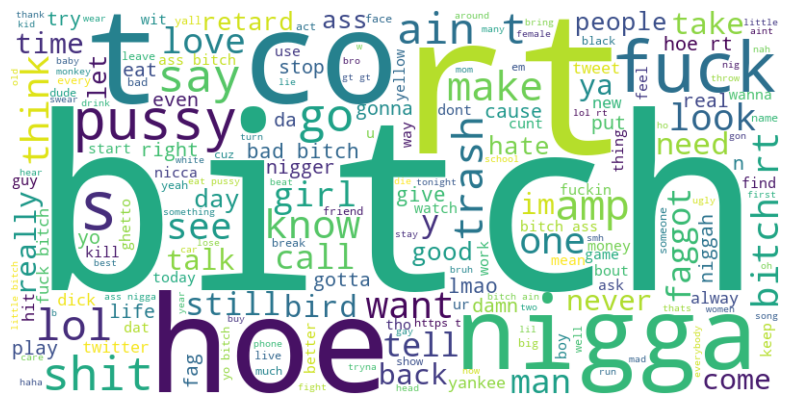

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(df['cleaned'].str.cat(sep=' '))

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('./outputs/figures/eda/wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()


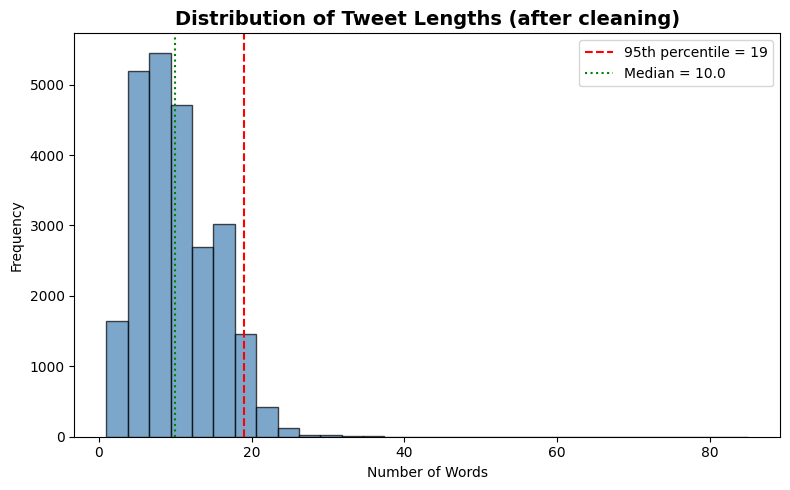

Max length: 85
95th percentile: 19
Median: 10


In [19]:
# EDA: Text length distribution
text_lengths = df['cleaned'].str.split().str.len()
plt.figure(figsize=(8, 5))
plt.hist(text_lengths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)

plt.axvline(x=np.percentile(text_lengths, 95), color='red', linestyle='--', label=f'95th percentile = {np.percentile(text_lengths,95):.0f}')

plt.axvline(x=text_lengths.median(), color='green', linestyle=':', label=f'Median = {text_lengths.median():.1f}')

plt.title('Distribution of Tweet Lengths (after cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
os.makedirs('./outputs/figures/eda', exist_ok=True)
plt.savefig('./outputs/figures/eda/text_length_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Max length: {text_lengths.max()}')
print(f'95th percentile: {np.percentile(text_lengths, 95):.0f}')
print(f'Median: {text_lengths.median():.0f}')


## Train test split

- Split the cleaned text and labels into train/test sets (80/20).
- Fix the random seed for reproducibility.
- We split before tokenization to avoid information leakage from the test set vocabulary.

In [20]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['cleaned'],
                                                    df['label'],
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 19826
Testing set size: 4957


## Tokenization and padding

- Fit a `Tokenizer` on training text only.
- Convert texts to integer sequences.
- Choose `max_length` as the 95th percentile of training sequence lengths.
- Pad sequences to a fixed length for Keras models.

- *_Using the 95th percentile avoids very long outliers while keeping most sequences intact._*

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize the Tokenizer
tokenizer = Tokenizer()

# Fit the tokenizer on the training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Determine the maximum sequence length based on the 95th percentile
max_length = int(np.percentile([len(seq) for seq in X_train_sequences], 95))

# Apply padding to the sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post')

print(f"Vocabulary size: {len(tokenizer.word_index) + 1}")
print(f"Maximum sequence length: {max_length}")

I0000 00:00:1778405044.189923   49757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778405044.496285   49757 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778405045.719777   49757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Vocabulary size: 28571
Maximum sequence length: 19


## Encode the labels

- Encode string labels into integer IDs using `LabelEncoder`.
- Keep the class mapping (`label_encoder.classes_`) for interpretation later.

- *_This converts labels into a format compatible with `sparse_categorical_crossentropy`._*

In [22]:
# encode the labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Encoded labels:", np.unique(y_train_encoded))
print(label_encoder.classes_)

Encoded labels: [0 1 2]
['hate speec' 'neither' 'offensive language']


### Define Common Callbacks for models

- Define a reusable callbacks bundle used by all models.
- Save best checkpoints and stop early when validation loss stops improving.

- **_Keeping callbacks consistent makes model comparisons fairer._**

In [23]:
# callbacks 
from tensorflow import keras
import os

os.makedirs('./model_checkpoints', exist_ok=True)

PATIENCE = 3

def callbacks(model_name: str): 
    """Create common training callbacks (checkpoint + early stopping).

    Args:
        model_name (str): Filename to save under `./model_checkpoints/`.

    Returns:
        list[keras.callbacks.Callback]: Callbacks for `model.fit()`.
    """
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f'./model_checkpoints/{model_name}',
            save_best_only=True,
            monitor='val_loss'
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE
        )
]


## Build Sequential RNN, with trainable Embedding layer

- Build a simple baseline sequence model: Embedding -> SimpleRNN -> Softmax.
- Train it with the same preprocessing, split, and callbacks used by other models.

- **_This baseline helps quantify how much LSTM and pretrained embeddings improve performance._**

In [24]:
# 1. Simple RNN with a trainable Embedding layer.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input

# Model 1: Simple RNN with trainable Embedding layer
model1 = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=100
    ),

    SimpleRNN(64),

    Dense(3, activation='softmax') # number of classes is 3, so we use softmax activation
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model1.summary()

I0000 00:00:1778405049.683786   49757 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 19, 100)        │     2,857,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,867,855 (10.94 MB)

 Trainable params: 2,867,855 (10.94 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the model
history1 = model1.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    callbacks=callbacks("simple_rnn.keras"),
    batch_size=32,
    validation_data=(X_test_padded, y_test_encoded)
)

Epoch 1/30


I0000 00:00:1778405051.185802   53467 service.cc:153] XLA service 0x395edb30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778405051.185820   53467 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778405051.222026   53467 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778405051.348872   53467 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778405051.366677   53467 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1291_grad_1446_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778405051.366755   53467 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1930__.24
I0000 00:00:1778405051.654394   53467 dot_search_space.cc:240] All configs were f

 42/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7007 - loss: 0.7878

I0000 00:00:1778405053.552744   53467 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


607/620 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8191 - loss: 0.5271

I0000 00:00:1778405056.436676   53468 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1291_grad_1446_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778405056.436741   53468 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1930__.24
I0000 00:00:1778405056.604257   53468 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778405056.988136   53646 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_29', 12 bytes spill stores, 12 bytes spill loads



620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8200 - loss: 0.5247

I0000 00:00:1778405059.077301   53460 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778405059.424268   53776 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 12 bytes spill stores, 12 bytes spill loads



620/620 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8624 - loss: 0.4122 - val_accuracy: 0.8935 - val_loss: 0.3369
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9426 - loss: 0.1755 - val_accuracy: 0.8376 - val_loss: 0.4910
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9813 - loss: 0.0590 - val_accuracy: 0.8665 - val_loss: 0.4856
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9914 - loss: 0.0273 - val_accuracy: 0.8586 - val_loss: 0.5910


## Build LSTM model with trainable Embedding layer

- Replace the SimpleRNN recurrent layer with an LSTM layer (same embedding setup).
- Train and evaluate using the same pipeline for a clean architecture comparison.

- **_LSTMs typically handle longer dependencies better than vanilla RNNs.**_

In [26]:
# LSTM with a trainable Embedding layer.
from tensorflow.keras.layers import LSTM

model2 = Sequential([
    Input(shape=(max_length,)),
    
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=100
    ),
    
    LSTM(64),
    Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 19, 100)        │     2,857,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,899,535 (11.06 MB)

 Trainable params: 2,899,535 (11.06 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history2 = model2.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    batch_size=32,
    callbacks=callbacks("simple_lstm.keras"),
    validation_data=(X_test_padded, y_test_encoded)
)

Epoch 1/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8694 - loss: 0.3850 - val_accuracy: 0.8945 - val_loss: 0.3004
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9293 - loss: 0.2144 - val_accuracy: 0.8959 - val_loss: 0.3346
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9608 - loss: 0.1230 - val_accuracy: 0.8850 - val_loss: 0.3369
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9784 - loss: 0.0700 - val_accuracy: 0.8618 - val_loss: 0.4439


## Build LSTM with pretrained Word2Vec embeddings.

- Load pretrained Word2Vec vectors (Google News 300d).
- Build an embedding matrix aligned with the tokenizer vocabulary.
- Initialize the Keras Embedding layer from this matrix and freeze it to test transfer via embeddings.

- **_Goal: test whether pretrained semantics improves macro-F1 under class imbalance._**

### Load pretrained vectors

In [28]:
# LSTM with pretrained Word2Vec embeddings.
import gensim.downloader as api

word2vec = api.load("word2vec-google-news-300")

### Build embedding matrix

In [29]:
embedding_dim = 300 # dimension of the word vectors 

embedding_matrix = np.zeros(
    (len(tokenizer.word_index) + 1, embedding_dim)
) # initialize the embedding matrix with zeros

for word, i in tokenizer.word_index.items():
    if word in word2vec:
        embedding_matrix[i] = word2vec[word] # fill the embedding matrix with the pretrained word vectors

In [30]:
# build LSTM model with pretrained embeddings
model3 = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix
    ],
        trainable=False # freeze the embedding layer
    ),

    LSTM(64),
    Dense(3, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 19, 300)        │     8,571,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,664,935 (33.05 MB)

 Trainable params: 93,635 (365.76 KB)

 Non-trainable params: 8,571,300 (32.70 MB)

In [31]:
history3 = model3.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    batch_size=32,
    callbacks=callbacks("lstm_pretrained.keras"),
    validation_data=(X_test_padded, y_test_encoded)
)

Epoch 1/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8698 - loss: 0.3707 - val_accuracy: 0.8884 - val_loss: 0.3342
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8942 - loss: 0.2893 - val_accuracy: 0.8886 - val_loss: 0.3076
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9013 - loss: 0.2692 - val_accuracy: 0.8963 - val_loss: 0.2949
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9083 - loss: 0.2524 - val_accuracy: 0.8927 - val_loss: 0.2899
Epoch 5/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9119 - loss: 0.2387 - val_accuracy: 0.8945 - val_loss: 0.2905
Epoch 6/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9150 - loss: 0.2290 - val_accuracy: 0.8943 - val_loss: 0.2859
Epoch 7/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9198 - loss: 0.2154 - val_accuracy: 0.8909 - val_loss: 0.2980
Epoch 8/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9246 - loss: 0.2051 - val_accuracy: 0.

### Model accuracy and loss visualization

- Plot accuracy/loss curves for each trained model.
- Use these curves to spot overfitting/underfitting and convergence differences.

- **_These plots support the discussion section in the written report._**

In [32]:
import matplotlib.pyplot as plt

def plot_history(history, model_name, save_path=None): 
    """
    This function plots the training and validation accuracy and loss curves for a given model history.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy subplot
    axes[0].plot(history.history['accuracy'])
    axes[0].plot(history.history['val_accuracy' ])

    axes[0].set_title(f'{model_name } Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(['Train', 'Validation' ])

    # Loss subplot
    axes[1].plot(history.history['loss' ])
    axes[1].plot(history.history['val_loss'])

    axes[1].set_title(f'{model_name } Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(['Train', 'Validation' ])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

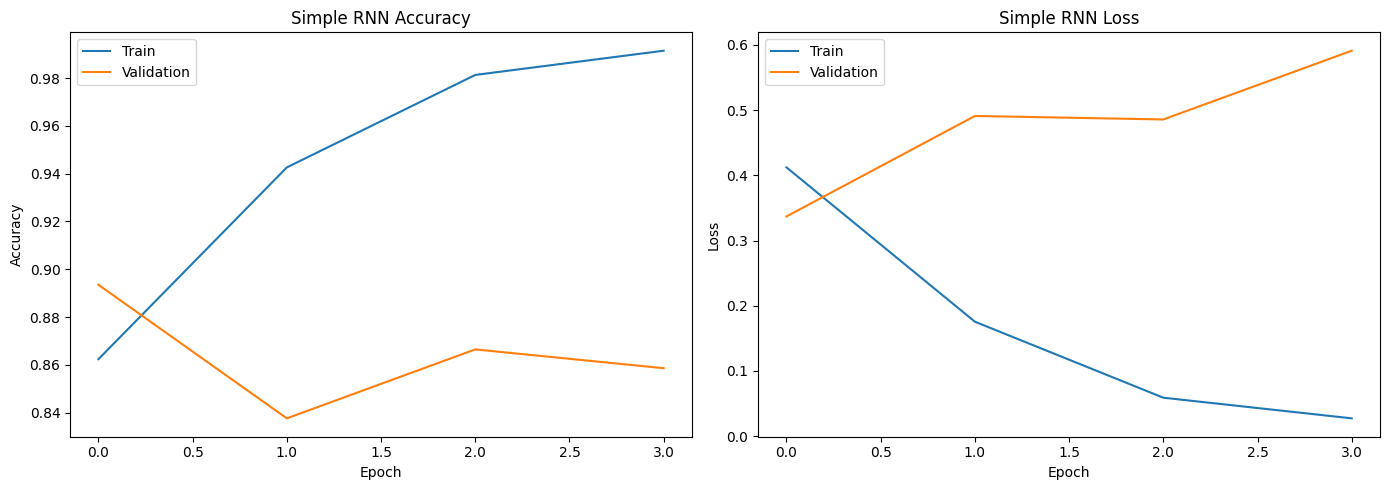

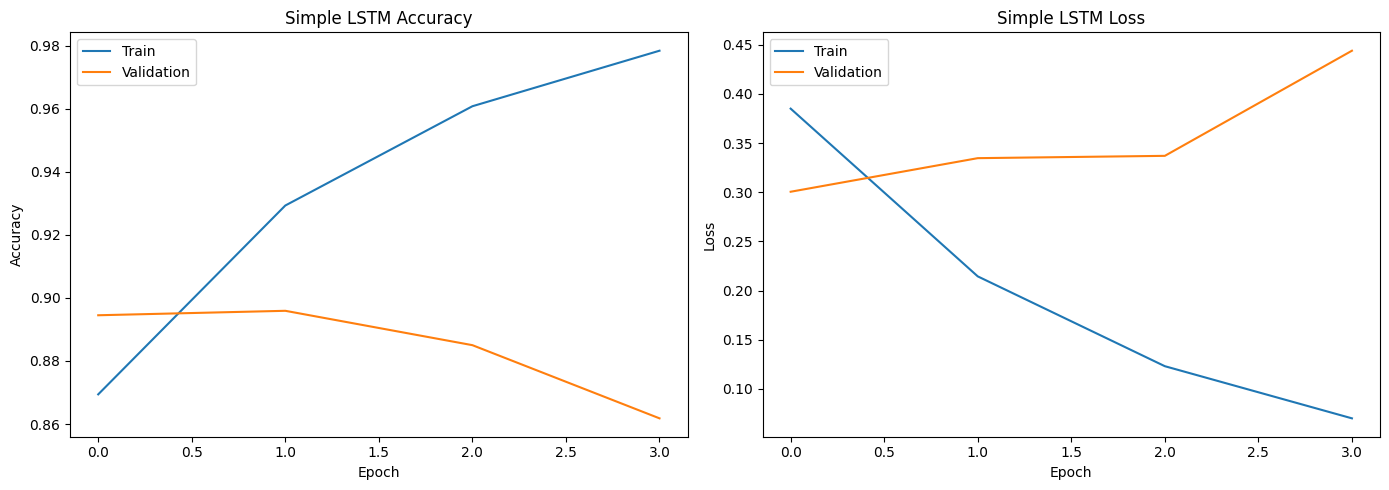

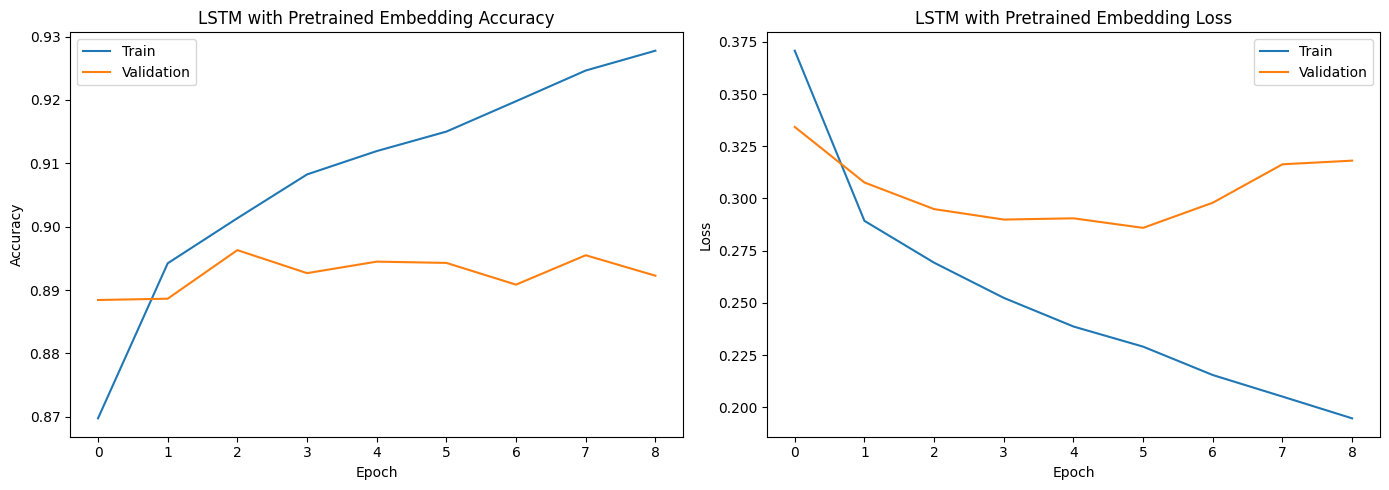

In [33]:
titles = [
    "Simple RNN",
    "Simple LSTM",
    "LSTM with Pretrained Embedding"
]

histories = [history1, history2, history3]

save_paths = [
    './outputs/figures/training_curves/simple_rnn_curves.png',
    './outputs/figures/training_curves/lstm_curves.png',
    './outputs/figures/training_curves/lstm_w2v_curves.png',
]

os.makedirs('./outputs/figures/training_curves', exist_ok=True)
for i, history in enumerate(histories):
    plot_history(history, titles[i], save_path=save_paths[i])

## Evaluation and Error analysis

- Evaluate each model on the held-out test set.
- Report accuracy, confusion matrix, and a classification report (including macro averages).
- Inspect a few misclassified examples for error analysis.

- **_Macro metrics are important here because the dataset is imbalanced._**

In [34]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import numpy as np
import os

def evaluate_model(
    model,
    X_test,
    y_test,
    encoder,
    model_name
):
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)

    accuracy = accuracy_score(y_test, y_pred_classes)
    print(f" {model_name} Accuracy: {accuracy:.4f}")

    cm = confusion_matrix(y_test, y_pred_classes)
    print("Confusion Matrix:")
    print(cm)

    print("Classification Report:")
    report = classification_report(
        y_test, y_pred_classes,
        target_names=encoder.classes_,
        output_dict=True,
    )
    print(classification_report(
        y_test, y_pred_classes,
        target_names=encoder.classes_,
    ))

    # Save confusion matrix figure
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(range(len(encoder.classes_)), encoder.classes_, rotation=30, ha='right')
    plt.yticks(range(len(encoder.classes_)), encoder.classes_)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j ], ha='center', va='center', fontsize=9)
    plt.tight_layout()
    os.makedirs('./outputs/figures/confusion_matrices', exist_ok=True)
    plt.savefig(f'./outputs/figures/confusion_matrices/{model_name.lower().replace(" ", "_")}_cm.png', bbox_inches='tight', dpi=150)
    plt.show()

    macro = report.get('macro avg', {})
    return accuracy, y_pred_classes, macro.get('precision'), macro.get('recall'), macro.get('f1-score')

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
 Simple RNN Accuracy: 0.8586
Confusion Matrix:
[[  46   37  207]
 [  12  633  190]
 [ 140  115 3577]]
Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.23      0.16      0.19       290
           neither       0.81      0.76      0.78       835
offensive language       0.90      0.93      0.92      3832

          accuracy                           0.86      4957
         macro avg       0.65      0.62      0.63      4957
      weighted avg       0.85      0.86      0.85      4957



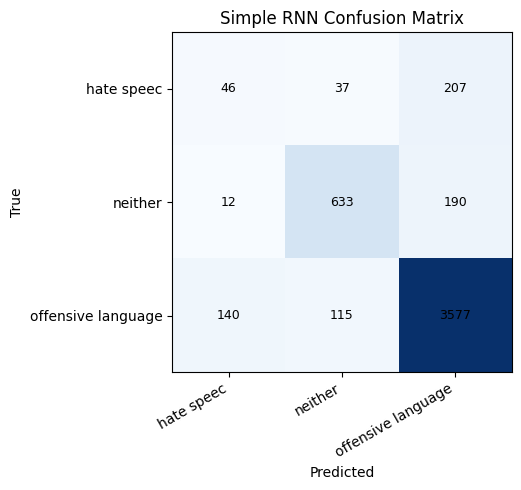

In [35]:
# evaluate model1: Simple RNN
_, y_pred_classes_model1, macro_precision_model1, macro_recall_model1, macro_f1_model1 = evaluate_model(
    model1,
    X_test_padded,
    y_test_encoded,
    label_encoder,
    titles[0]
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
 Simple LSTM Accuracy: 0.8618
Confusion Matrix:
[[ 120   33  137]
 [  27  702  106]
 [ 261  121 3450]]
Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.29      0.41      0.34       290
           neither       0.82      0.84      0.83       835
offensive language       0.93      0.90      0.92      3832

          accuracy                           0.86      4957
         macro avg       0.68      0.72      0.70      4957
      weighted avg       0.88      0.86      0.87      4957



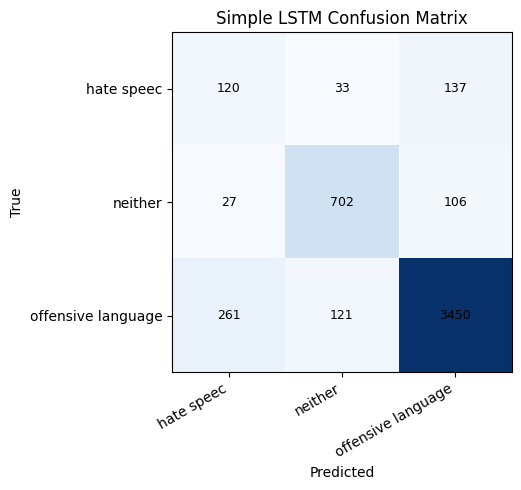

In [36]:
# evaluate model2: Simple LSTM
_, y_pred_classes_model2, macro_precision_model2, macro_recall_model2, macro_f1_model2 = evaluate_model(
    model2,
    X_test_padded,
    y_test_encoded,
    label_encoder,
    titles[1]
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
 LSTM with Pretrained Embedding Accuracy: 0.8923
Confusion Matrix:
[[  75   29  186]
 [  32  697  106]
 [  77  104 3651]]
Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.41      0.26      0.32       290
           neither       0.84      0.83      0.84       835
offensive language       0.93      0.95      0.94      3832

          accuracy                           0.89      4957
         macro avg       0.72      0.68      0.70      4957
      weighted avg       0.88      0.89      0.89      4957



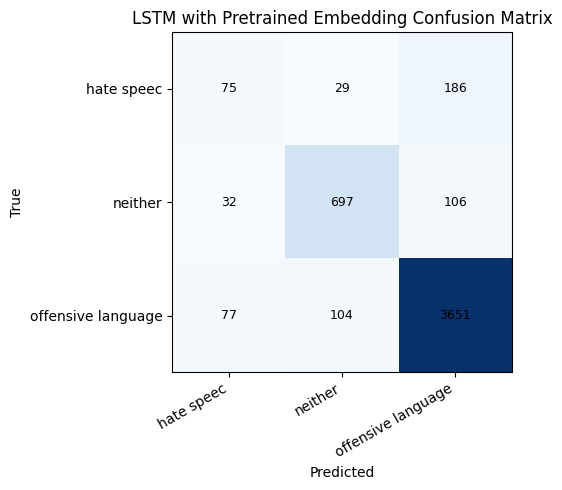

In [37]:
# evaluate model3: LSTM with pretrained embeddings
_, y_pred_classes_model3, macro_precision_model3, macro_recall_model3, macro_f1_model3 = evaluate_model(
    model3,
    X_test_padded,
    y_test_encoded,
    label_encoder,
    titles[2]
)

## Error Analysis and discussion

- Printed a few misclassified examples.
- Compare true vs predicted labels and annotate likely causes (short context, sarcasm, overlap between classes).

- _**This supports the qualitative discussion in the report.**_

In [38]:
for i in range(len(y_pred_classes_model1)):
    if y_pred_classes_model1[i] != y_test_encoded[i]:
        print("Tweet:", X_test.iloc[i])
        print("Actual:", y_test_encoded[i])
        print("Predicted:", y_pred_classes_model1[i])
        print("---")

Tweet: rt eanahs__ 1inkkofrosess lol credit ain t near good know right man job ho nice though
Actual: 1
Predicted: 2
---
Tweet: nien_nunb search gay redneck episode 1 play
Actual: 0
Predicted: 2
---
Tweet: keebithalal loganswarning gotta love islamofascist cow try make retort age typical muzzie idiocy
Actual: 0
Predicted: 1
---
Tweet: 8220 ashlynwynns mud shark black friends make perfect sense 128514 128557 128514 128557 idiotic 8221
Actual: 1
Predicted: 2
---
Tweet: allsportsbruh say waste draft pick manziel mallet that s tell delete account retard
Actual: 0
Predicted: 1
---
Tweet: rt letsargueboxing staycoolwheels scream like little bitch lmaooo
Actual: 2
Predicted: 0
---
Tweet: rt rihannahasaids aight game over dyke ruin http t co o0can6gb1p
Actual: 0
Predicted: 1
---
Tweet: ain t real nigga without goal chase yellow bone bitch w toe paint
Actual: 2
Predicted: 0
---
Tweet: rt wolfpackalan oreos first twist it you aw crap break
Actual: 2
Predicted: 1
---
Tweet: iamshady_ that s even 

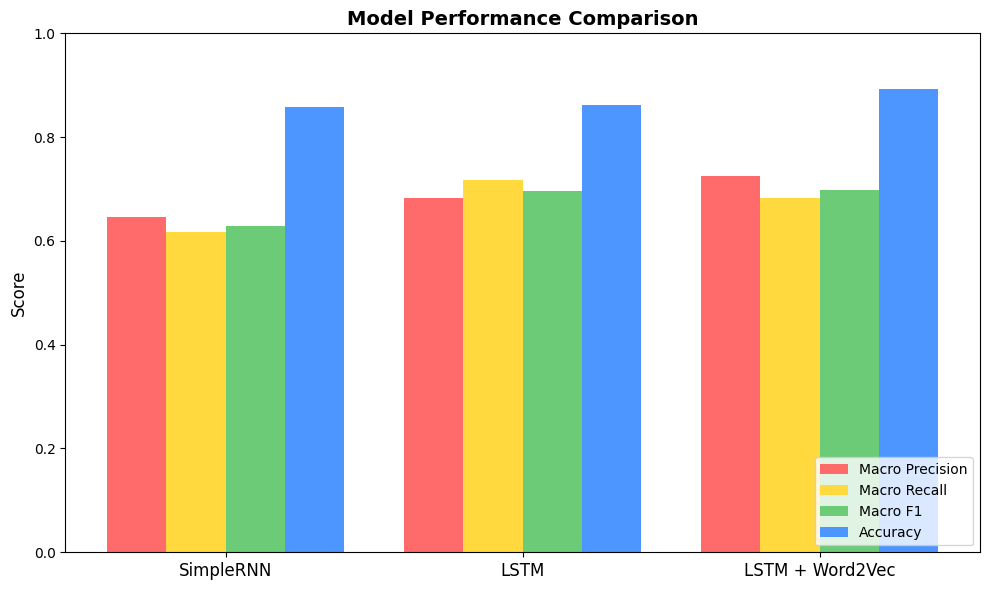

In [40]:
# Final model comparison bar chart — using actual evaluation metrics
import numpy as np

models = ['SimpleRNN', 'LSTM', 'LSTM + Word2Vec']

macro_p = [macro_precision_model1, macro_precision_model2, macro_precision_model3]
macro_r = [macro_recall_model1, macro_recall_model2, macro_recall_model3]
macro_f1 = [macro_f1_model1, macro_f1_model2, macro_f1_model3]
accuracies = [accuracy_score(y_test_encoded, y_pred_classes_model1), accuracy_score(y_test_encoded, y_pred_classes_model2), accuracy_score(y_test_encoded, y_pred_classes_model3)]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - width*1.5, macro_p, width, label='Macro Precision', color='#ff6b6b')
plt.bar(x - width/2, macro_r, width, label='Macro Recall', color='#ffd93d')
plt.bar(x + width/2, macro_f1, width, label='Macro F1', color='#6bcb77')
plt.bar(x + width*1.5, accuracies, width, label='Accuracy', color='#4d96ff')

plt.xticks(x, models, fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0,1.0)
plt.legend(loc='lower right')
plt.tight_layout()
os.makedirs('./outputs/figures/comparisons', exist_ok=True)
plt.savefig('./outputs/figures/comparisons/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## UI using gradio (optional)

- Wrap preprocessing + tokenization + model inference into a `predict_tweet` helper.
- Build a minimal Gradio UI for interactive testing.

- **_This makes it easy to try edge cases and demonstrate the classifier._**

In [42]:
import gradio as gr

def predict_tweet(text): 
    """Predict the class label for a user-provided tweet string.

    Uses the same preprocessing, tokenizer, and padding settings as training,
    then runs the trained model and decodes the predicted label.

    Args:
        text (str): Raw tweet text.

    Returns:
        str: Predicted label (one of the original dataset label strings).
    """
    cleaned = text_cleaning_pipeline(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(seq, maxlen=max_length)
    pred = model2.predict(padded)

    label = label_encoder.inverse_transform([pred.argmax() ])[0]
    return label

gr.Interface(
    fn=predict_tweet,
    inputs="text",
    outputs="text"
).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
